<h1 style="text-align:center;color:blue">Don't forget to Upvote if you like it.😊</h1>

# **Introduction**


In this kernal we will going through the whole process of creating a Machine Learning on the Heart Disease dataset. It predicts the patients which can survive by considering various features.

<h4 style='color:red'>There are many risk factors for heart diseases: age, sex, tobacco use, physical inactivity, excessive alcohol consumption, unhealthy diet, obesity, genetic predisposition and family history of cardiovascular disease, raised blood pressure (hypertension), raised blood sugar,etc. We will predict heart disease in this model by considering various such factors</h4>

![](https://www.health.harvard.edu/media/content/images/p2_QA_MLJuly19_gi484761271.jpg)

<h1>Importing Libraries</h1>

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/heart-disease-uci/heart.csv


<h1>Importing Dataset</h1>

In [2]:
df=pd.read_csv('/kaggle/input/heart-disease-uci/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


<h1>Data Preprocessing</h1>

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [5]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


<h1>Data Visualization</h1>

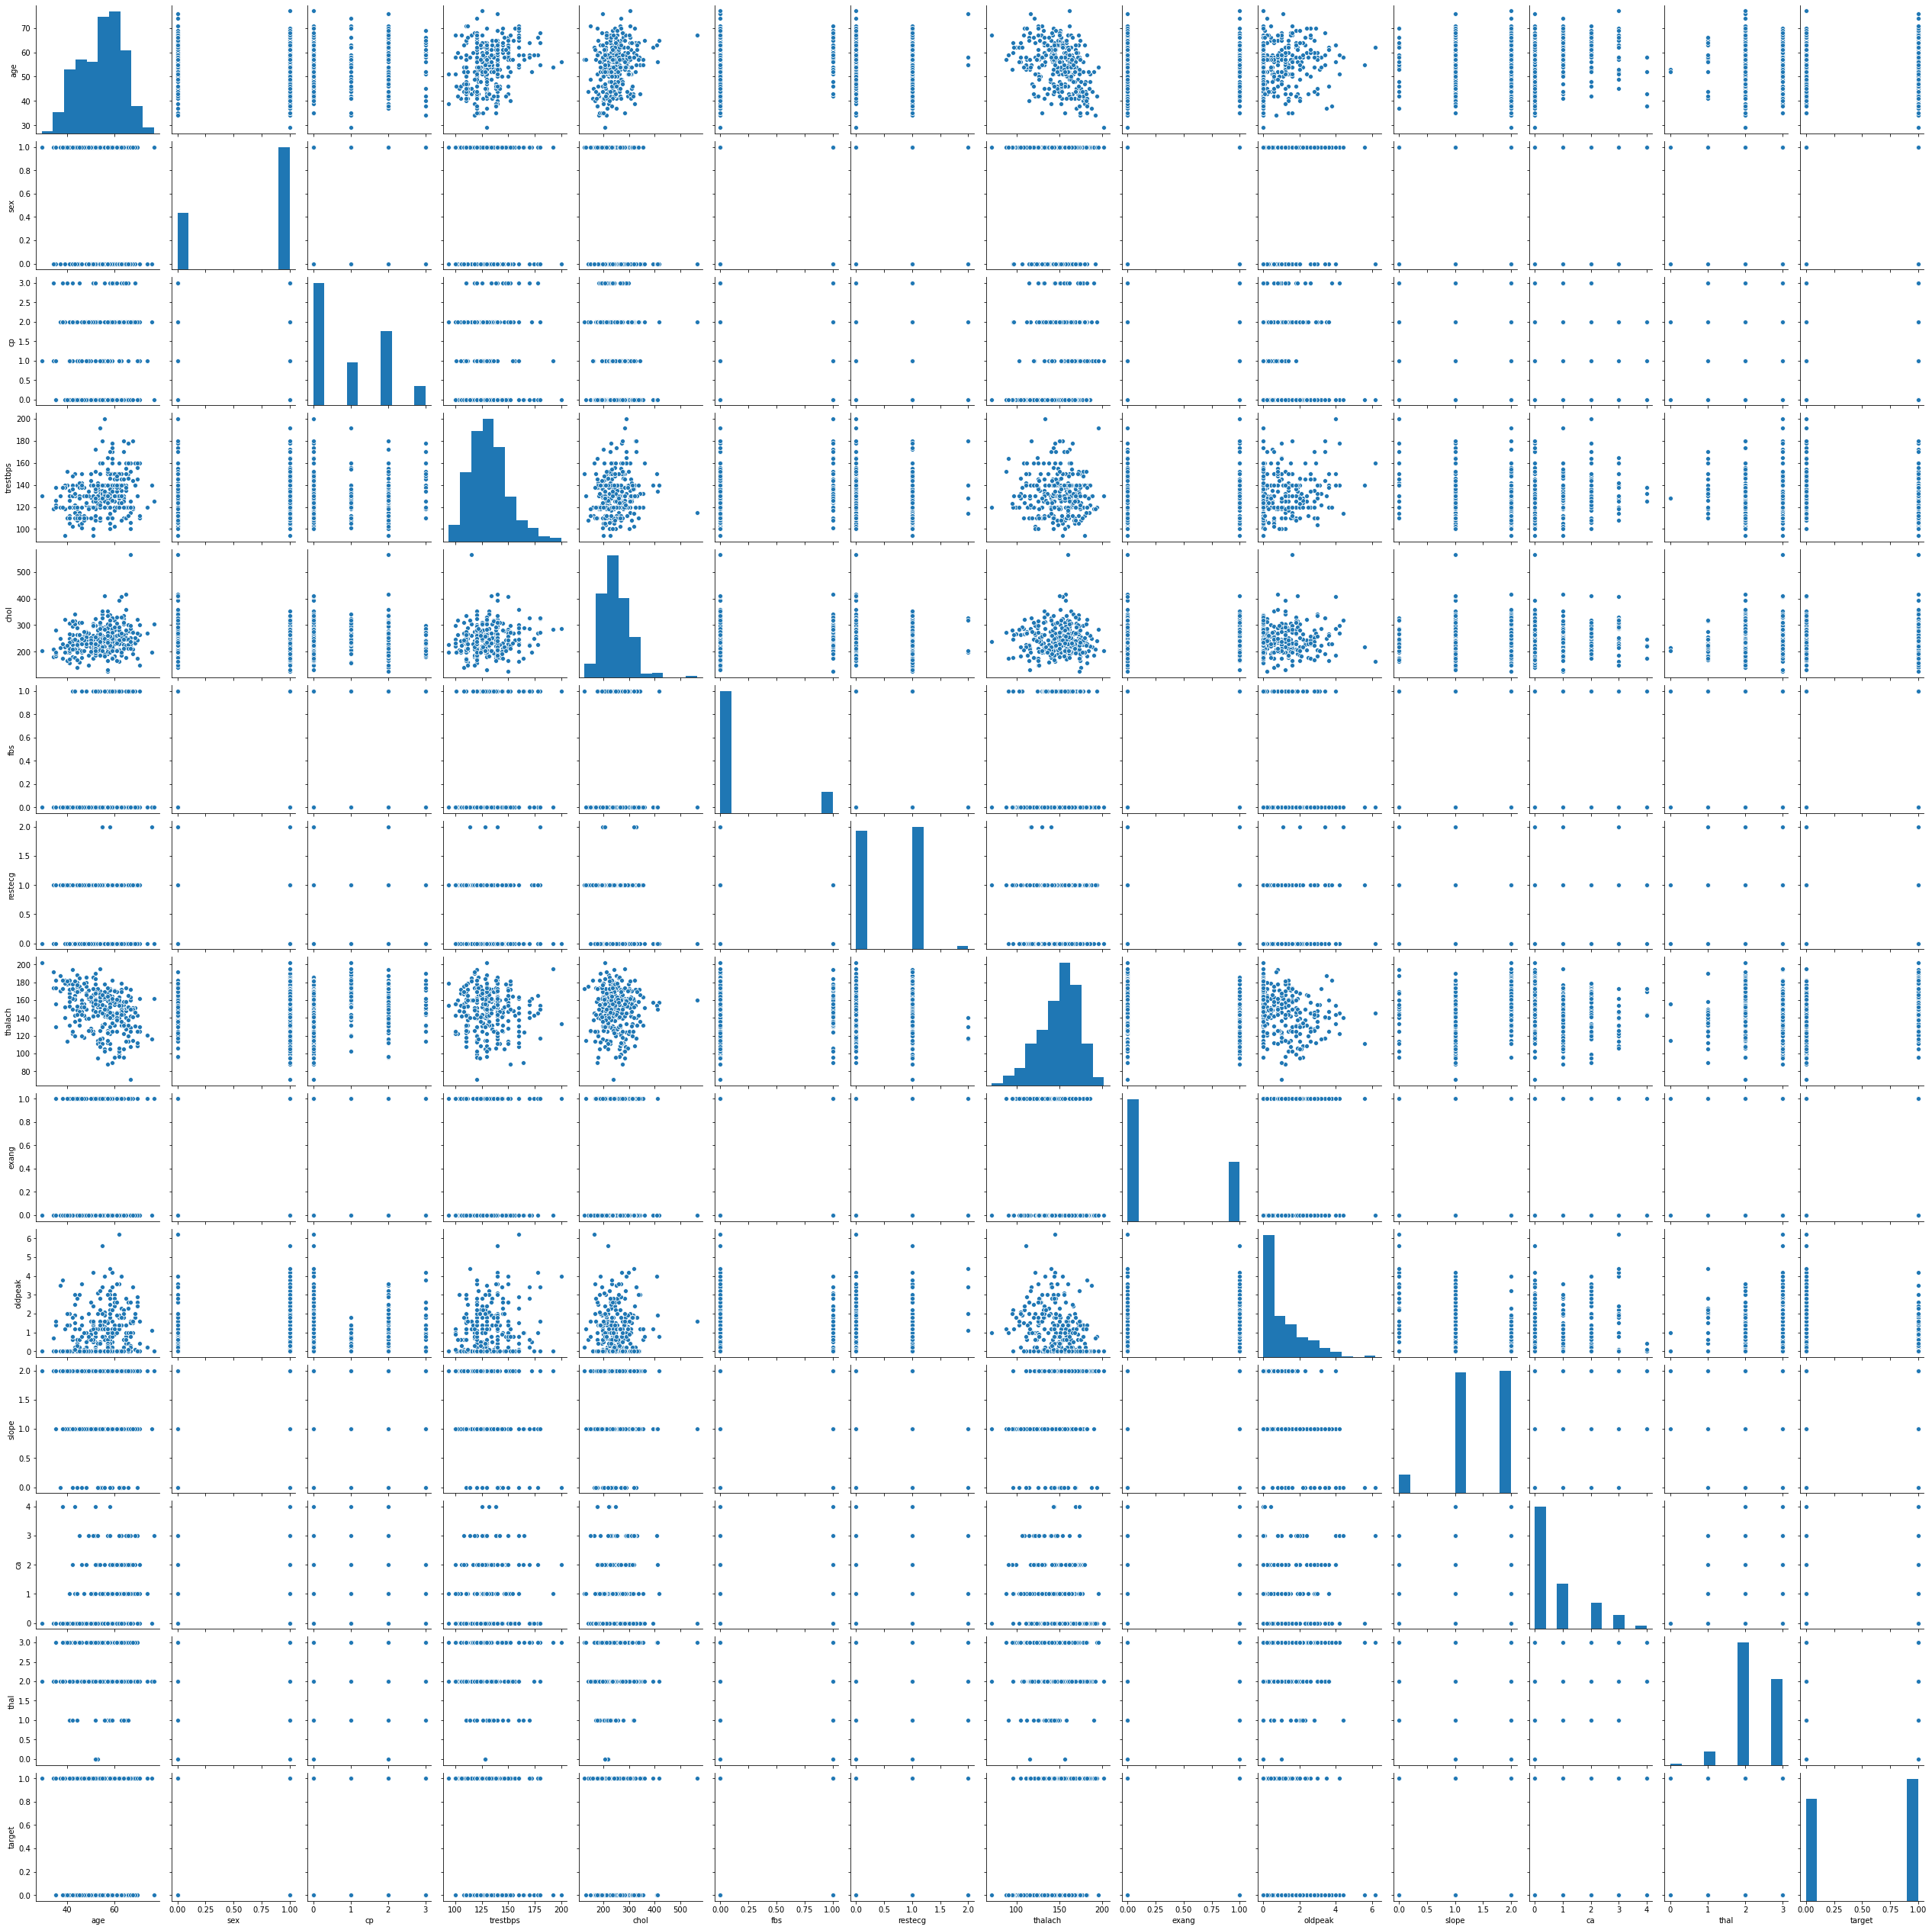

In [6]:
import seaborn as sns
sns.pairplot(df)

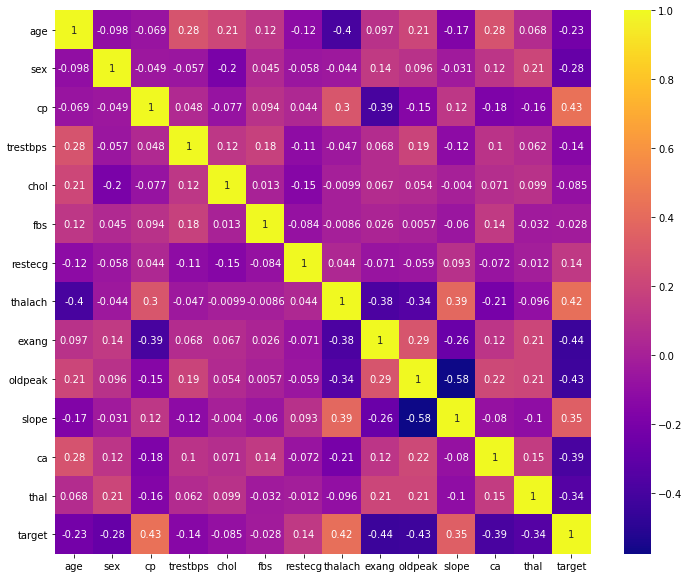

In [7]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True,cmap=plt.cm.plasma)

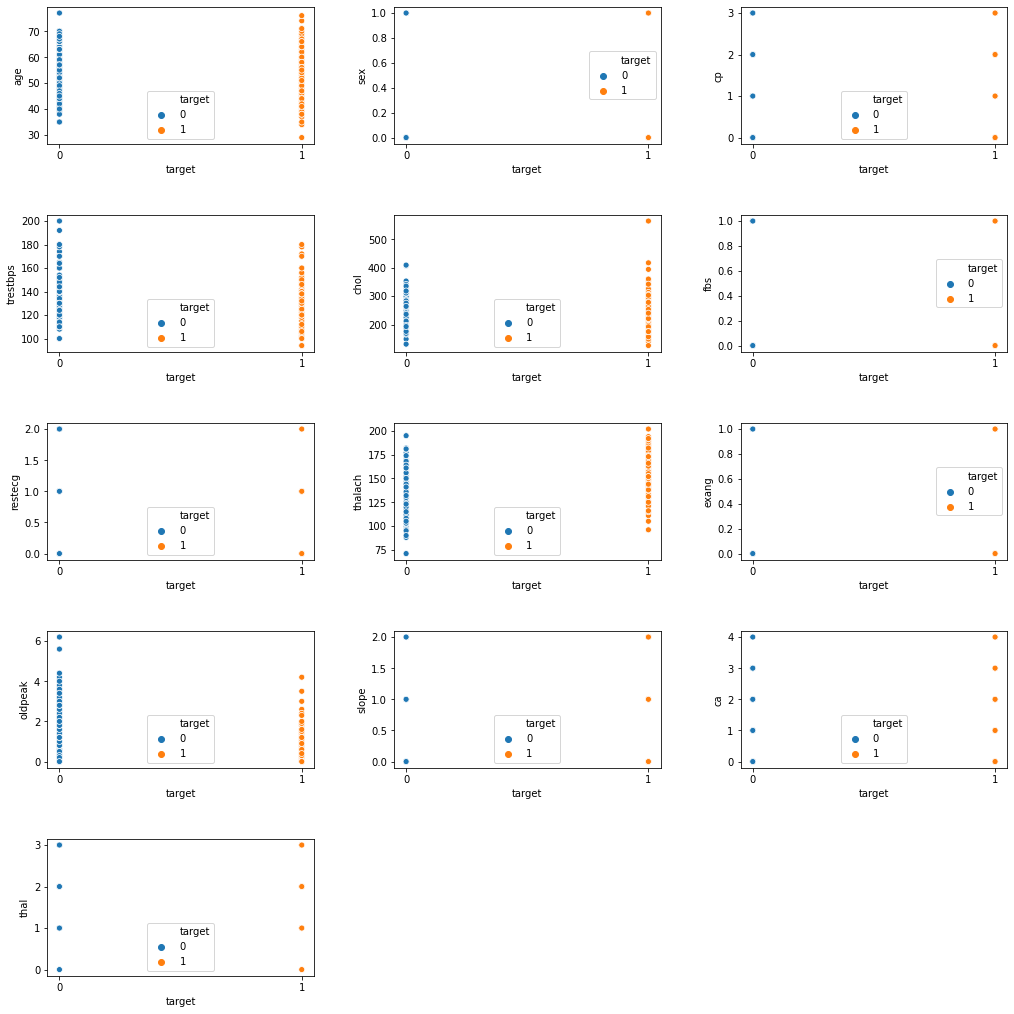

In [8]:
plt.figure(figsize=(15,15))
for i in range(len(df.columns)-1):
    plt.subplot(5,3,i+1)
    sns.scatterplot(df['target'],df[df.columns[i]],hue=df['target'])
    plt.xticks([0,1])
plt.tight_layout(pad=4.0)

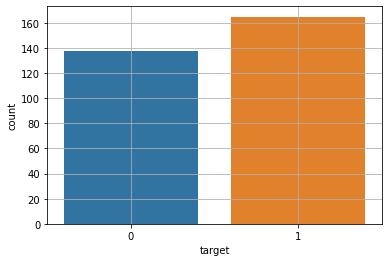

In [9]:
sns.countplot(df['target'],data=df)
plt.grid()

# **Building and Training the Model**

In [10]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X=df.drop('target',axis=1)
Y=df['target']
df=sc.fit(X).transform(X)
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.25,random_state=3)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

<h3>We will train model function in which we will train the data for 6 Different Algorithms</h3>

In [12]:
def model(X_train,y_train):
    models=[]
    
    lr=LogisticRegression(max_iter=1000)
    lr.fit(X_train,y_train)
    models.append(lr)
    
    tree=DecisionTreeClassifier(random_state=42)
    tree.fit(X_train,y_train)
    models.append(tree)
    
    svm=SVC(kernel='rbf', gamma=0.1, C=1.0)
    svm.fit(X_train,y_train)
    models.append(svm)
    
    knn=KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train,y_train)
    models.append(knn)
    
    rfc=RandomForestClassifier()
    rfc.fit(X_train,y_train)
    models.append(rfc)
    
    nb=GaussianNB()
    nb.fit(X_train,y_train)
    models.append(nb)
    
    return models

In [13]:
models=model(X_train,y_train)

In [14]:
from sklearn.metrics import accuracy_score
train_accuracy=[]
test_accuracy=[]

for i in range(6):
    yhat=models[i].predict(X_test)
    yhat_t=models[i].predict(X_train)
    train_accuracy.append(accuracy_score(yhat_t,y_train))
    test_accuracy.append(accuracy_score(yhat,y_test))

In [15]:
Model=['LogisticRegression','DecisionTreeClassifier','SVC','KNeighborsClassifier','RandomForestClassifier','GaussianNB']

In [16]:
Accuracy_score=pd.DataFrame({ 
    'Model':Model,
    'Train_Accuracy':train_accuracy,
    'Test_Accuracy':test_accuracy
})

<h1>Finding Best Model</h1>

<h4>Below is the accuracy score for testing and training data for various Models</h4>

In [17]:
Accuracy_score

,Model,Train_Accuracy,Test_Accuracy
0,LogisticRegression,0.854626,0.881579
1,DecisionTreeClassifier,1.000000,0.750000
2,SVC,1.000000,0.605263
3,KNeighborsClassifier,0.775330,0.631579
4,RandomForestClassifier,1.000000,0.828947
5,GaussianNB,0.828194,0.881579


In [18]:
score=dict(zip(Model, Accuracy_score['Test_Accuracy'].values)) 
score={k: v for k, v in sorted(score.items(), key=lambda item: item[1])}

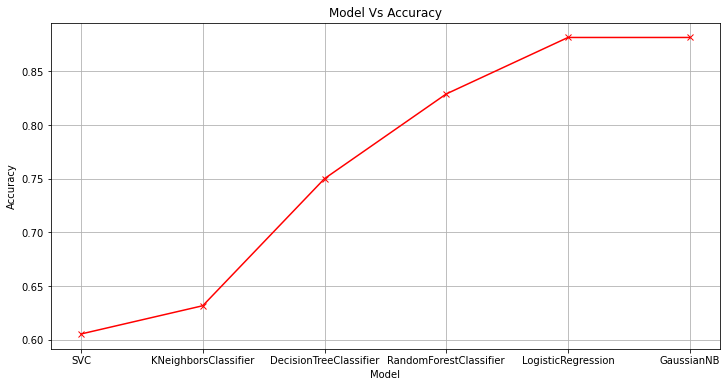

In [19]:
plt.figure(figsize=(12,6))
plt.plot(list(score.keys()),list(score.values()),marker='x',color='red')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Vs Accuracy')
plt.grid()